# Long-form KaiB — survey across known cyanobacteria

**Question:** How widespread is the long-form KaiB (KaiB-long) among sequenced cyanobacteria?

The canonical short-form KaiB (~100 aa, TIGR02654/PF07689) is the well-characterised circadian clock component. A structurally distinct long-form KaiB (~240 aa) has been described in *Anabaena* PCC 7120 and a small number of other strains. Its phylogenetic distribution is poorly characterised.

**Approach:**
1. Fetch all RefSeq cyanobacteria assembly accessions (~2,500 genomes)
2. Download protein FASTAs for each assembly in batches, cached per-genome
3. Search with `hmmsearch` using the `KaiB_longform_Anabaena7120` profile from `db/kai_hmm/KaiABC_correct.hmm`
4. Collate hits with metadata (organism, assembly level, taxonomy)
5. Visualise distribution across cyanobacterial orders
6. Compare short-form vs long-form prevalence
7. Download TARA Oceans MAG protein sequences (Delmont 2018 / Tully 2018)
8. Run hmmsearch on TARA data
9. Parse and merge TARA hits with RefSeq results
10. Combined RefSeq vs TARA visualisation

**Runtime:** ~2–4 hours for RefSeq steps (NCBI download rate-limited). All steps cached — safe to interrupt and resume.

## Setup

In [16]:
from pathlib import Path
import sys, subprocess, time, json, gzip
from Bio import Entrez, SeqIO
import pandas as pd

# Bootstrap: find project root and load shared utilities
_p = Path.cwd().resolve()
for _parent in [_p] + list(_p.parents):
    if (_parent / "Snakefile").exists():
        sys.path.insert(0, str(_parent / "notebooks"))
        break
from utils import find_project_root, load_config

PROJECT = find_project_root()
cfg     = load_config()

Entrez.email   = cfg.get("entrez_email", "jaepeiso@gmail.com")
Entrez.api_key = cfg.get("ncbi_api_key")   # 10 req/s vs 3 req/s without

# ── Paths ─────────────────────────────────────────────────────────────────────
OUT_DIR  = PROJECT / "results" / "kai_survey"
PROT_DIR = OUT_DIR / "proteins"              # one .faa.gz per assembly
HMM_DB   = PROJECT / "db" / "kai_hmm" / "KaiABC_correct.hmm"
HITS_TSV = OUT_DIR / "longKaiB_hits.tsv"
META_TSV = OUT_DIR / "assembly_metadata.tsv"
FIG_DIR  = PROJECT / "results" / "figures"

for d in [OUT_DIR, PROT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT)
print("HMM DB:      ", HMM_DB)
print("Output dir:  ", OUT_DIR)
print("API key set: ", bool(Entrez.api_key))


Project root: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome
HMM DB:       /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/db/kai_hmm/KaiABC_correct.hmm
Output dir:   /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey
API key set:  True


## Tool check

In [17]:
import shutil

_required = {
    "hmmsearch": "HMMER (conda: hmmer)",
    "hmmfetch":  "HMMER (conda: hmmer)",
}
_missing = {k: v for k, v in _required.items() if not shutil.which(k)}
if _missing:
    raise EnvironmentError(
        "Missing tools:\n" + "\n".join(f"  {k} — install: {v}" for k, v in _missing.items())
    )
print("All tools found.")

# Confirm the longKaiB profile is present in the HMM database
hmm_names = [l.split()[1] for l in HMM_DB.read_text().splitlines() if l.startswith("NAME")]
print(f"Profiles in {HMM_DB.name}: {hmm_names}")
if "KaiB_longform_Anabaena7120" not in hmm_names:
    raise ValueError("KaiB_longform_Anabaena7120 not found in HMM DB — run db/kai_hmm/add_longKaiB.py first")


All tools found.
Profiles in KaiABC_correct.hmm: ['KaiA', 'KaiA_N', 'circ_KaiB', 'circ_KaiC', 'KaiB_longform_Anabaena7120']


## Step 1: Fetch RefSeq cyanobacteria assembly list

Retrieves all current RefSeq cyanobacteria assemblies and caches their accession + metadata to `assembly_metadata.tsv`. Re-running skips the fetch if the file already exists.

In [18]:
# ── 1. Fetch all RefSeq cyanobacteria assembly accessions ────────────────────
# Includes FtpPath_RefSeq — used in Step 2 to download protein FASTAs directly
# from NCBI FTP without needing elink.
# Delete assembly_metadata.tsv to force a refresh.

BATCH = 500

if META_TSV.exists():
    df_meta = pd.read_csv(META_TSV, sep="\t")
    print(f"Loaded cached metadata: {len(df_meta):,} assemblies")
    if "ftp_path" not in df_meta.columns:
        print("WARNING: cached metadata missing ftp_path — delete assembly_metadata.tsv and rerun")
else:
    print("Searching NCBI for RefSeq cyanobacteria assemblies...")
    handle = Entrez.esearch(
        db="assembly",
        term="Cyanobacteria[Organism] AND latest_refseq[filter]",
        retmax=10_000
    )
    search = Entrez.read(handle); handle.close()
    ids = search["IdList"]
    print(f"Found {len(ids):,} assemblies")

    records = []
    for i in range(0, len(ids), BATCH):
        batch = ids[i:i+BATCH]
        handle = Entrez.esummary(db="assembly", id=",".join(batch))
        summaries = Entrez.read(handle)["DocumentSummarySet"]["DocumentSummary"]
        handle.close()
        for s in summaries:
            ftp = s.get("FtpPath_RefSeq", "")
            records.append({
                "assembly_accession": s.get("AssemblyAccession", ""),
                "assembly_name":      s.get("AssemblyName", ""),
                "organism":           s.get("Organism", ""),
                "taxid":              s.get("Taxid", ""),
                "assembly_level":     s.get("AssemblyStatus", ""),
                "refseq_category":    s.get("RefSeq_category", ""),
                "biosample":          s.get("BioSampleAccn", ""),
                "ftp_path":           ftp,
            })
        print(f"  {min(i+BATCH, len(ids))}/{len(ids)} summaries fetched")
        time.sleep(0.12 if Entrez.api_key else 0.35)

    df_meta = pd.DataFrame(records)
    df_meta.to_csv(META_TSV, sep="\t", index=False)
    print(f"Saved → {META_TSV.name}")

no_ftp = (df_meta["ftp_path"] == "") | df_meta["ftp_path"].isna()
print(f"\nAssemblies with FTP path: {(~no_ftp).sum():,} / {len(df_meta):,}")
print(df_meta["assembly_level"].value_counts().to_string())


Loaded cached metadata: 2,536 assemblies

Assemblies with FTP path: 2,536 / 2,536
assembly_level
Contig             1311
Scaffold            777
Complete Genome     407
Chromosome           41


## Step 2: Download protein FASTAs

Downloads `protein.faa.gz` for each assembly directly from the NCBI FTP path stored in the metadata. Each file is saved as `{accession}.faa.gz`. Already-downloaded genomes are skipped — safe to interrupt and resume.

This is the main runtime step (~1–3 hours with API key).

In [19]:
# ── 2. Download protein FASTAs via NCBI FTP ───────────────────────────────────
# FTP path format (from metadata):
#   https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/.../GCF_xxx_ASMyyy/
# Protein FASTA filename:
#   {accession}_{assembly_name}_protein.faa.gz
#
# We use curl (streaming, resumable) rather than urllib to handle large files.

import subprocess

SLEEP   = 0.12 if Entrez.api_key else 0.35
n_done  = n_skip = n_fail = n_noftp = 0

rows = df_meta[df_meta["ftp_path"].notna() & (df_meta["ftp_path"] != "")].itertuples()

for row in rows:
    acc      = row.assembly_accession
    asm_name = row.assembly_name
    ftp_base = row.ftp_path.replace("ftp://", "https://")  # use HTTPS

    out_path = PROT_DIR / f"{acc}.faa.gz"
    if out_path.exists() and out_path.stat().st_size > 100:
        n_skip += 1
        continue

    # Filename convention: {accession}_{assembly_name}_protein.faa.gz
    fname = f"{acc}_{asm_name}_protein.faa.gz"
    url   = f"{ftp_base}/{fname}"

    result = subprocess.run(
        ["curl", "-fsSL", "--retry", "3", "--retry-delay", "2",
         "-o", str(out_path), url],
        capture_output=True
    )
    if result.returncode != 0 or not out_path.exists() or out_path.stat().st_size < 100:
        # Some assemblies genuinely have no protein file (non-coding/RNA only)
        if out_path.exists():
            out_path.unlink()
        n_fail += 1
    else:
        n_done += 1

    total = n_done + n_skip + n_fail
    if total % 100 == 0:
        print(f"  {total}/{len(df_meta)}  downloaded={n_done}  skipped={n_skip}  failed={n_fail}")
    time.sleep(SLEEP)

n_noftp = (df_meta["ftp_path"].isna() | (df_meta["ftp_path"] == "")).sum()
print(f"\nDone.")
print(f"  Downloaded : {n_done:,}")
print(f"  Skipped    : {n_skip:,}  (already cached)")
print(f"  Failed     : {n_fail:,}  (no protein file or download error)")
print(f"  No FTP path: {n_noftp:,}")
print(f"  Protein files on disk: {sum(1 for _ in PROT_DIR.glob('*.faa.gz')):,}")



Done.
  Downloaded : 0
  Skipped    : 2,518  (already cached)
  Failed     : 18  (no protein file or download error)
  No FTP path: 0
  Protein files on disk: 2,518


## Step 3: hmmsearch for KaiB-long

Concatenates all protein FASTAs into a single database and runs `hmmsearch` with only the `KaiB_longform_Anabaena7120` profile. Uses all available CPU cores. Result cached to `longKaiB_hits.tsv`.

In [20]:
# ── 3. Run hmmsearch against all proteins ────────────────────────────────────
# NOTE: if you re-downloaded proteins after a failed run, delete
# all_cyano_proteins.faa and longKaiB_tblout.txt before rerunning this cell.
import shutil

CONCAT_FA  = OUT_DIR / "all_cyano_proteins.faa"
TBLOUT     = OUT_DIR / "longKaiB_tblout.txt"
LONGKAIB_HMM  = OUT_DIR / "KaiB_longform.hmm"   # extracted long-form profile
SHORTKAIB_HMM = OUT_DIR / "KaiB_short.hmm"       # extracted short-form profile
TBLOUT_SHORT  = OUT_DIR / "shortKaiB_tblout.txt"

# Extract long-form and short-form profiles separately
for hmm_out, profile_name in [
    (LONGKAIB_HMM,  'KaiB_longform_Anabaena7120'),
    (SHORTKAIB_HMM, 'circ_KaiB'),
]:
    if not hmm_out.exists():
        result = subprocess.run(
            ['hmmfetch', str(HMM_DB), profile_name],
            capture_output=True, text=True
        )
        hmm_out.write_text(result.stdout)
        print(f'Extracted profile → {hmm_out.name}')

# Concatenate protein FASTAs (streaming, avoids loading all into memory)
if not CONCAT_FA.exists() or CONCAT_FA.stat().st_size < 1000:
    print("Concatenating protein FASTAs...")
    faa_files = sorted(PROT_DIR.glob("*.faa.gz"))
    with open(CONCAT_FA, "w") as out_fh:
        for faa in faa_files:
            # Prefix each header with assembly accession for traceability
            acc = faa.stem  # e.g. GCF_000006745.1
            with gzip.open(faa, "rt") as in_fh:
                for line in in_fh:
                    if line.startswith(">"):
                        out_fh.write(f">{acc}|{line[1:]}")
                    else:
                        out_fh.write(line)
    print(f"Concatenated → {CONCAT_FA.name}  ({CONCAT_FA.stat().st_size/1e9:.2f} GB)")
else:
    print(f"Using existing concat: {CONCAT_FA.name}")

# Run hmmsearch
if not TBLOUT.exists():
    n_cpu = subprocess.run(["sysctl", "-n", "hw.logicalcpu"], capture_output=True, text=True)
    n_cpu = n_cpu.stdout.strip() or "4"
    print(f"Running hmmsearch on {n_cpu} CPUs...")
    subprocess.run(
        ["hmmsearch",
         "--tblout", str(TBLOUT),
         "--noali",         # suppress alignment output (faster)
         "-E", "1e-5",      # report threshold (generous; we filter below)
         "--cpu", n_cpu,
         str(LONGKAIB_HMM), str(CONCAT_FA)],
        check=True
    )
    print(f"Done → {TBLOUT.name}")
else:
    print(f'Using cached tblout: {TBLOUT.name}')

# Short-form hmmsearch — no score threshold needed (circ_KaiB is specific)
if not TBLOUT_SHORT.exists():
    print('Running hmmsearch for short-form KaiB...')
    subprocess.run(
        ['hmmsearch',
         '--tblout', str(TBLOUT_SHORT),
         '--noali', '-E', '1e-5',
         '--cpu', n_cpu,
         str(SHORTKAIB_HMM), str(CONCAT_FA)],
        check=True
    )
    print(f'Done → {TBLOUT_SHORT.name}')
else:
    print(f'Using cached tblout: {TBLOUT_SHORT.name}')


Using existing concat: all_cyano_proteins.faa
Using cached tblout: longKaiB_tblout.txt
Using cached tblout: shortKaiB_tblout.txt


## Step 4: Parse hits and join metadata

Filters hmmsearch results to a strong e-value threshold (1e-10), maps each hit back to its source assembly accession, and joins organism + taxonomy metadata.

In [21]:
# ── 4. Parse tblout and join assembly metadata ───────────────────────────────
EVALUE_CUTOFF = 1e-10

# Score threshold: the single-sequence HMM cross-detects short-form KaiB at
# scores 50-155. Genuine long-form hits cluster at score >= 200 (clear bimodal
# gap in the distribution). Apply both e-value AND score cutoffs.
SCORE_CUTOFF  = 200.0   # separates long-form from short-form cross-hits

rows = []
with open(TBLOUT) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        cols = line.split()
        evalue = float(cols[4])
        score  = float(cols[5])
        if evalue > EVALUE_CUTOFF or score < SCORE_CUTOFF:
            continue
        # Header format: {assembly_acc}.faa|{original_protein_header}
        # Strip .faa suffix so accession matches metadata table
        header  = cols[0]
        asm_acc = header.split("|")[0].removesuffix(".faa")
        prot_id = "|".join(header.split("|")[1:])
        rows.append({
            "assembly_accession": asm_acc,
            "protein_id":         prot_id,
            "evalue":             evalue,
            "score":              score,
        })

df_hits = pd.DataFrame(rows) if rows else pd.DataFrame(
    columns=["assembly_accession","protein_id","evalue","score"])

# Join metadata
df_hits = df_hits.merge(df_meta, on="assembly_accession", how="left")

# One row per assembly (keep best hit per genome)
df_best = (df_hits.sort_values("evalue")
           .groupby("assembly_accession", as_index=False)
           .first())

df_best.to_csv(HITS_TSV, sep='\t', index=False)

# ── Parse short-form hits ────────────────────────────────────────────────
short_rows = []
with open(TBLOUT_SHORT) as f:
    for line in f:
        if line.startswith('#') or not line.strip(): continue
        cols = line.split()
        if float(cols[4]) > EVALUE_CUTOFF: continue
        asm_acc = cols[0].split('|')[0].removesuffix('.faa')
        short_rows.append({'assembly_accession': asm_acc, 'short_evalue': float(cols[4])})

df_short = (pd.DataFrame(short_rows)
            .sort_values('short_evalue')
            .groupby('assembly_accession', as_index=False).first())

short_accs = set(df_short['assembly_accession'])
all_accs   = set(df_meta['assembly_accession'])
long_accs  = set(df_best['assembly_accession'])

n_both      = len(long_accs & short_accs)
n_long_only = len(long_accs - short_accs)
n_short_only = len(short_accs - long_accs)
n_neither   = len(all_accs - long_accs - short_accs)

print(f'Short-form KaiB: {len(short_accs):,} assemblies ({100*len(short_accs)/len(df_meta):.1f}%)')
print(f'Long-form only:  {n_long_only:,}')
print(f'Short-form only: {n_short_only:,}')
print(f'Both forms:      {n_both:,}')
print(f'Neither:         {n_neither:,}')
print(f"KaiB-long hits (e ≤ {EVALUE_CUTOFF:.0e}, score ≥ {SCORE_CUTOFF:.0f}): {len(df_best):,} assemblies")
print(f"Out of {len(df_meta):,} total RefSeq cyanobacteria")
print(f"Prevalence: {100*len(df_best)/len(df_meta):.1f}%")
print()
print(df_best[["organism","assembly_level","evalue","score"]]
      .sort_values("evalue").to_string(index=False))


Short-form KaiB: 2,481 assemblies (97.8%)
Long-form only:  0
Short-form only: 778
Both forms:      1,703
Neither:         55
KaiB-long hits (e ≤ 1e-10, score ≥ 200): 1,703 assemblies
Out of 2,536 total RefSeq cyanobacteria
Prevalence: 67.2%

                                                                          organism  assembly_level        evalue  score
                                   Nostoc sp. PCC 7120 = FACHB-418 (cyanobacteria) Complete Genome 1.800000e-175  590.7
                                   Trichormus variabilis FACHB-171 (cyanobacteria)          Contig 1.800000e-175  590.7
                                            Anabaena sp. FACHB-709 (cyanobacteria) Complete Genome 1.800000e-175  590.7
                                     Anabaena cylindrica FACHB-170 (cyanobacteria)          Contig 1.800000e-175  590.7
                                            Anabaena sp. FACHB-709 (cyanobacteria)          Contig 1.800000e-175  590.7
                                   Nos

## Step 5: Visualise distribution

Bar chart of KaiB-long hit counts grouped by cyanobacterial order, with assembly-level breakdown (complete / scaffold / contig).

Fetching lineage for hit genomes...


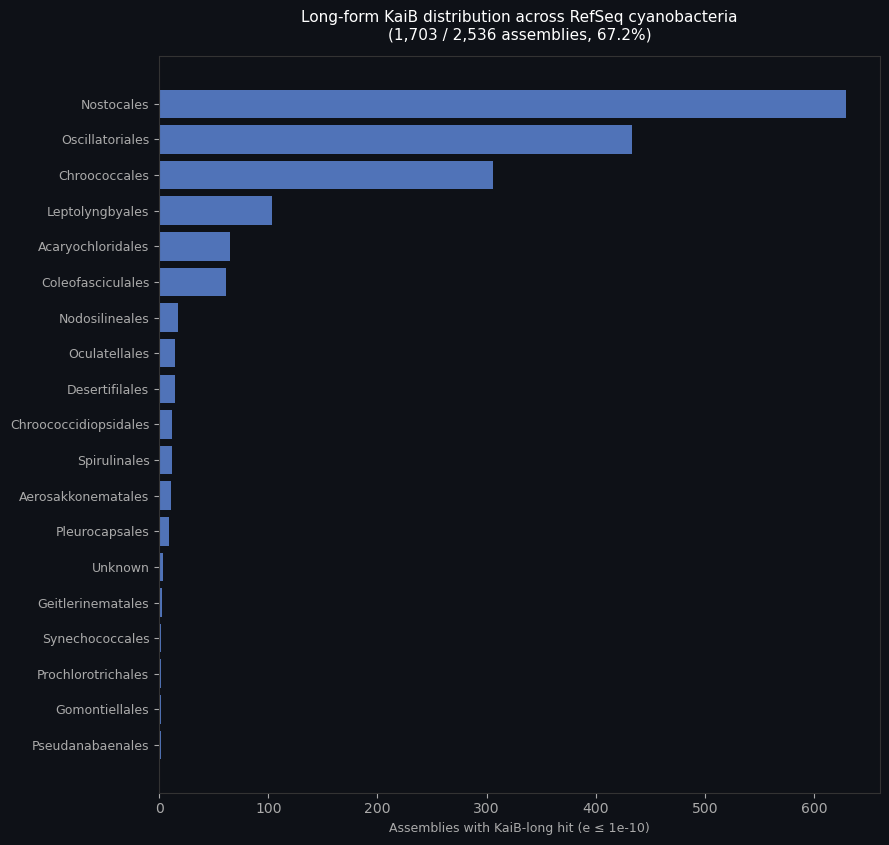

Saved → longKaiB_survey.pdf


In [22]:
# ── 5. Distribution plot across cyanobacterial orders ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

BG = "#0e1117"

# Extract order from organism string where possible
# (RefSeq organism field is typically "Genus species (strain)" — no lineage)
# Use taxid to fetch lineage for hit genomes only (small number of requests)
def get_order(taxid):
    """Fetch lineage for a taxid and return the order-level name."""
    try:
        handle = Entrez.efetch(db="taxonomy", id=str(taxid), retmode="xml")
        records = Entrez.read(handle); handle.close()
        for taxon in records[0].get("LineageEx", []):
            if taxon["Rank"] == "order":
                return taxon["ScientificName"]
    except Exception:
        pass
    return "Unknown"

if "order" not in df_best.columns:
    print("Fetching lineage for hit genomes...")
    orders = {}
    for taxid in df_best["taxid"].unique():
        orders[str(taxid)] = get_order(taxid)
        time.sleep(0.12 if Entrez.api_key else 0.35)
    df_best["order"] = df_best["taxid"].astype(str).map(orders)
    df_best.to_csv(HITS_TSV, sep="\t", index=False)  # update cache

# Count by order
order_counts = df_best.groupby("order").size().sort_values(ascending=True)

LEVEL_COLORS = {
    "Complete Genome": "#20AD62",
    "Chromosome":      "#5BC8AF",
    "Scaffold":        "#5C85D6",
    "Contig":          "#D97B4A",
}

fig, ax = plt.subplots(figsize=(9, max(4, len(order_counts)*0.45)),
                        facecolor=BG)
ax.set_facecolor(BG)

y = range(len(order_counts))
ax.barh(list(y), order_counts.values, color="#5C85D6", alpha=0.85)
ax.set_yticks(list(y))
ax.set_yticklabels(order_counts.index, fontsize=9, color="white")
ax.set_xlabel("Assemblies with KaiB-long hit (e ≤ 1e-10)", color="#aaa", fontsize=9)
ax.tick_params(colors="#aaa")
ax.spines[:].set_color("#333")
ax.set_title(
    f"Long-form KaiB distribution across RefSeq cyanobacteria\n"
    f"({len(df_best):,} / {len(df_meta):,} assemblies, {100*len(df_best)/len(df_meta):.1f}%)",
    color="white", fontsize=11, pad=12
)

plt.tight_layout()
out = FIG_DIR / "longKaiB_survey.pdf"
plt.savefig(out, dpi=200, bbox_inches="tight", facecolor=BG)
plt.savefig(out.with_suffix(".png"), dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Saved → {out.name}")


## Step 6: Short-form vs long-form KaiB — stacked comparison

Stacked bar chart per order showing assemblies with: both forms, long-form only, short-form only, and neither.

Fetching lineage for 687 unresolved taxids...
Done


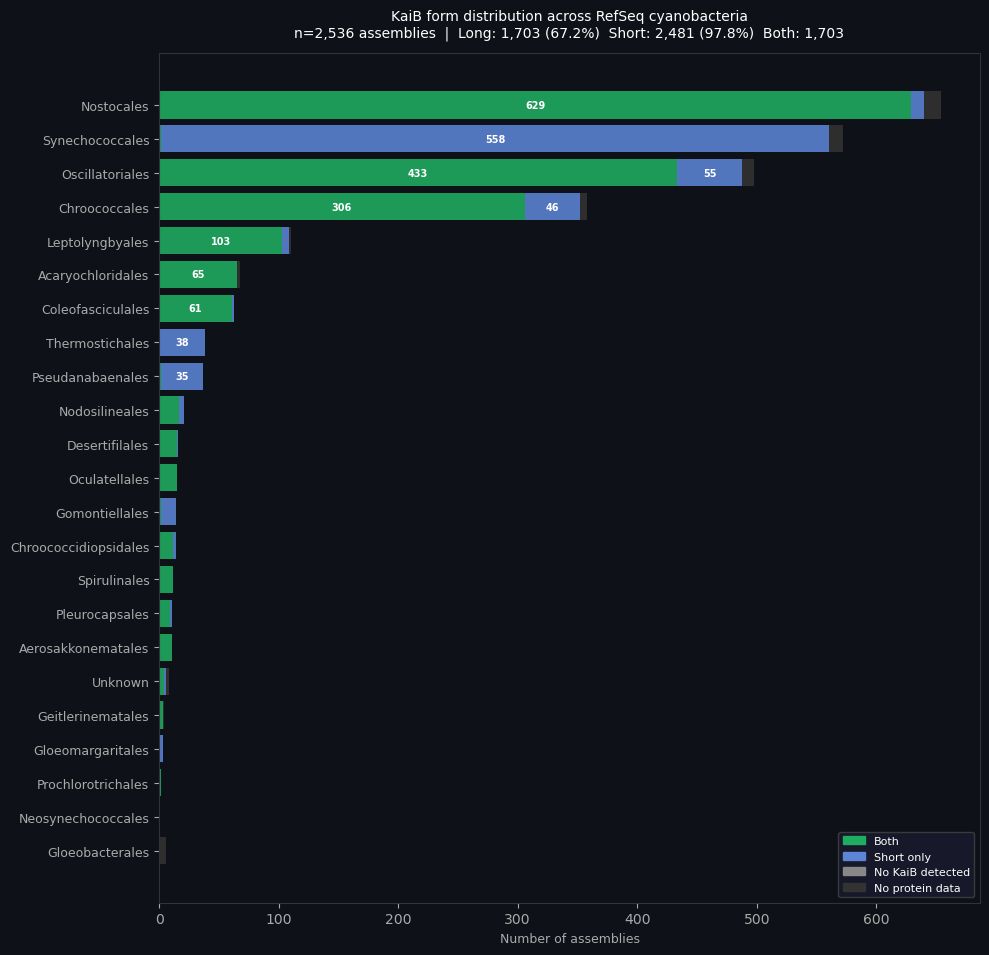

Saved → longKaiB_vs_shortKaiB.pdf


In [36]:
# ── 6. Stacked bar: short / long / both / neither per order ──────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG = '#0e1117'

# Tag every assembly with its KaiB status
# Build taxid → order map from df_best (covers all hit taxids).
# For non-hit assemblies sharing a taxid with a hit, order resolves correctly.
# Remaining unknowns are fetched in a small batch.
df_all = df_meta[['assembly_accession', 'organism', 'assembly_level', 'taxid']].copy()

taxid_order = {}
if 'order' in df_best.columns:
    for _, row in df_best.iterrows():
        if pd.notna(row.get('order')) and row['order'] != 'Unknown':
            taxid_order[str(row['taxid'])] = row['order']

df_all['order'] = df_all['taxid'].astype(str).map(taxid_order)

# Fetch orders for remaining unknown taxids in batches
unknown_taxids = df_all[df_all['order'].isna()]['taxid'].unique().tolist()
if unknown_taxids:
    print(f"Fetching lineage for {len(unknown_taxids)} unresolved taxids...")
    BATCH = 200
    for i in range(0, len(unknown_taxids), BATCH):
        batch = [str(t) for t in unknown_taxids[i:i+BATCH]]
        try:
            handle = Entrez.efetch(db="taxonomy", id=",".join(batch), retmode="xml")
            records = Entrez.read(handle); handle.close()
            for rec in records:
                tid = str(rec['TaxId'])
                order = next(
                    (t['ScientificName'] for t in rec.get('LineageEx', [])
                     if t['Rank'] == 'order'), 'Unknown'
                )
                taxid_order[tid] = order
        except Exception as e:
            print(f"  Batch {i//BATCH} failed: {e}")
        time.sleep(0.12 if Entrez.api_key else 0.35)
    df_all['order'] = df_all['taxid'].astype(str).map(taxid_order).fillna('Unknown')
    print("Done")
df_all['has_long'] = df_all['assembly_accession'].isin(long_accs)
df_all['has_short'] = df_all['assembly_accession'].isin(short_accs)

import os
has_prot = {p.stem for p in (OUT_DIR / 'proteins').glob('*.faa.gz')}

def kaib_status(row):
    if row['has_long'] and row['has_short']:  return 'Both'
    if row['has_long']:                        return 'Long only'
    if row['has_short']:                       return 'Short only'
    if row['assembly_accession'] not in has_prot: return 'No protein data'
    return 'No KaiB detected'

df_all['status'] = df_all.apply(kaib_status, axis=1)

# Count per order × status
pivot = (df_all.groupby(['order', 'status'])
         .size().unstack(fill_value=0)
         .reindex(columns=['Both', 'Long only', 'Short only',
                           'No KaiB detected', 'No protein data'], fill_value=0))

# Sort by total assemblies with any hit (descending)
pivot['_total_hit'] = pivot['Both'] + pivot['Long only'] + pivot['Short only']
pivot = pivot.sort_values('_total_hit').drop(columns='_total_hit')

COLORS = {
    'Both':             '#20AD62',
    'Long only':        '#E8824E',
    'Short only':       '#5C85D6',
    'No KaiB detected': '#888888',
    'No protein data':  '#333333',
}

fig, ax = plt.subplots(figsize=(10, max(5, len(pivot)*0.42)), facecolor=BG)
ax.set_facecolor(BG)

left = np.zeros(len(pivot))
y    = np.arange(len(pivot))
for status, color in COLORS.items():
    vals = pivot[status].values
    ax.barh(y, vals, left=left, color=color, label=status, alpha=0.88)
    # Label bars wider than ~30
    for yi, (v, l) in enumerate(zip(vals, left)):
        if v >= 30:
            ax.text(l + v/2, yi, str(v), ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize=9, color='white')
ax.set_xlabel('Number of assemblies', color='#aaa', fontsize=9)
ax.tick_params(colors='#aaa')
ax.spines[:].set_color('#333')

# Omit 'Long only' from legend since it has 0 entries
handles = [mpatches.Patch(color=COLORS[s], label=s)
           for s in COLORS if s != 'Long only']
ax.legend(handles=handles, fontsize=8, facecolor='#1a1a2e',
          edgecolor='#444', labelcolor='white', loc='lower right')

ax.set_title(
    'KaiB form distribution across RefSeq cyanobacteria\n'
    f'n={len(df_meta):,} assemblies  |  '
    f'Long: {len(long_accs):,} ({100*len(long_accs)/len(df_meta):.1f}%)  '
    f'Short: {len(short_accs):,} ({100*len(short_accs)/len(df_meta):.1f}%)  '
    f'Both: {n_both:,}',
    color='white', fontsize=10, pad=12
)

plt.tight_layout()
out = FIG_DIR / 'longKaiB_vs_shortKaiB.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {out.name}')


## Step 7: Download TARA Oceans MAGs

Downloads the Delmont et al. (2018) non-redundant bacterial/archaeal MAGs (1,888 genomes, 4.5M genes)
and the Tully et al. (2018) TOBG dataset (2,631 MAGs) for comparison with RefSeq cyanobacteria.

**Data sources:**
- Delmont 2018: [Figshare 4902923](https://figshare.com/articles/dataset/TARA-NON-REDUNDANT-MAGs/4902923) — nucleotide FASTA (957 NR MAGs)
- Delmont 2018: [Figshare 4902917](https://figshare.com/articles/dataset/HBDs-AA-SEQUENCE-DATABASE/4902917) — amino acid sequences from all co-assemblies
- Tully 2018: [Figshare 5188273](https://figshare.com/articles/dataset/5188273) — 2,631 TOBG draft genomes (nucleotide)
- OGA2 BAC_ARC_MAGs: 1,888 curated bacterial/archaeal MAGs with 4.5M genes (used in Ocean Gene Atlas v2)

For protein-level HMM searches, we need amino acid sequences. The Delmont amino acid database
(`figshare:4902917`) provides pre-called proteins from all co-assembly scaffolds. For TOBG genomes
(nucleotide only), we run Prodigal/Pyrodigal to predict ORFs.

**Strategy:** Download the Delmont AA database (most convenient, pre-called proteins from the
same pipeline that produced the MAGs). If TOBG genomes are also desired, download and run
Prodigal on them separately. All steps cached — safe to interrupt and resume.

**Runtime:** Download ~5–15 min depending on connection; Prodigal ~10–30 min for TOBG genomes.

In [24]:
# ── 7. Download TARA Oceans MAG protein sequences ────────────────────────────
# Two datasets:
#   (a) Delmont et al. 2018 — amino acid sequences from co-assemblies (Figshare 4902917)
#       These are proteins predicted from ALL scaffolds in the co-assemblies,
#       not just the binned MAGs. This is the broadest search space.
#   (b) Tully et al. 2018 — TOBG draft genomes (Figshare 5188273)
#       Nucleotide only → requires Prodigal to predict proteins.
#
# We download (a) by default. Set INCLUDE_TOBG = True to also download (b).
#
# NOTE: Figshare article downloads are streaming ZIPs (no End-of-Central-Directory
#       record). Python's zipfile module cannot read these. We use a custom reader
#       that parses local file headers and copies each inner .fa.gz directly.

INCLUDE_TOBG = False  # Set True to also process Tully 2018 TOBG genomes

TARA_DIR      = OUT_DIR / "tara_oceans"
TARA_PROT_DIR = TARA_DIR / "proteins"
TOBG_DIR      = TARA_DIR / "tobg_genomes"
TOBG_PROT_DIR = TARA_DIR / "tobg_proteins"

for d in [TARA_DIR, TARA_PROT_DIR, TOBG_DIR, TOBG_PROT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Streaming ZIP reader ─────────────────────────────────────────────────────
import struct, zlib as _zlib

def _copy_gzip_entry(f, out_path):
    """
    Copy one complete gzip member from binary file handle f to out_path.
    Uses zlib.decompressobj to find the exact end of the DEFLATE payload
    without buffering the decompressed content in memory.
    After return, f is positioned at the first byte after the gzip footer.
    """
    gz_start = f.tell()
    
    # Parse gzip header to skip to DEFLATE payload
    assert f.read(2) == b'\x1f\x8b', "Expected gzip magic"
    f.read(1)             # compression method
    flg = f.read(1)[0]    # flags
    f.read(6)             # mtime(4) + xfl(1) + os(1)
    if flg & 4:   f.read(_struct_unpack('<H', f.read(2))[0])   # FEXTRA
    if flg & 8:            # FNAME - null-terminated
        while f.read(1) not in (b'\x00', b''): pass
    if flg & 16:           # FCOMMENT - null-terminated
        while f.read(1) not in (b'\x00', b''): pass
    if flg & 2:   f.read(2)   # FHCRC

    # Scan DEFLATE stream with zlib to find its end
    d = _zlib.decompressobj(-15)
    while True:
        chunk = f.read(65536)
        if not chunk:
            raise EOFError(f"Unexpected EOF while reading DEFLATE stream for {out_path.name}")
        d.decompress(chunk)   # discard output — we only need to find the stream end
        if d.eof:
            # unused_data contains bytes read past the DEFLATE end
            f.seek(-len(d.unused_data), 1)
            break

    f.read(8)  # gzip footer: CRC32 (4) + ISIZE (4)
    gz_end = f.tell()

    # Seek back and copy raw gzip bytes intact
    f.seek(gz_start)
    out_path.write_bytes(f.read(gz_end - gz_start))

# Alias used above (struct.unpack)
_struct_unpack = struct.unpack

def _extract_streaming_zip(zip_path, out_dir, verbose=True):
    """
    Extract all entries from a streaming ZIP (no EOCD) into out_dir.
    Each stored (method=0) entry that is a gzip file is copied as-is.
    Returns list of extracted Paths.
    """
    LOCAL_SIG     = b'PK\x03\x04'
    DATA_DESC_SIG = b'PK\x07\x08'
    out_dir       = Path(out_dir)
    extracted     = []

    with open(zip_path, 'rb') as f:
        while True:
            sig = f.read(4)
            if sig != LOCAL_SIG:
                break

            ver, flags, method, mtime, mdate, crc_h, cs_h, us_h, fn_len, ex_len = \
                struct.unpack('<HHHHHIIIHH', f.read(26))
            fname = f.read(fn_len).decode('utf-8', errors='replace')
            f.read(ex_len)   # skip extra field

            out_path = out_dir / Path(fname).name
            data_desc_mode = bool(flags & 0x08)

            if method != 0:
                raise ValueError(f"Unsupported ZIP compression method {method} for {fname!r}. "
                                 "Expected stored (method=0).")

            if cs_h > 0:
                # Size known in local header (common even when data descriptor flag is set)
                out_path.write_bytes(f.read(cs_h))
                # Skip optional data descriptor if present
                if data_desc_mode:
                    maybe = f.read(4)
                    if maybe == DATA_DESC_SIG:
                        f.read(12)
                    elif maybe:
                        f.seek(-4, 1)
            else:
                # Size = 0 in header (true streaming mode): use gzip stream end detection
                peek = f.read(2)
                f.seek(-2, 1)
                if peek == b'\x1f\x8b':
                    _copy_gzip_entry(f, out_path)
                else:
                    raise ValueError(f"method=0, size=0, but data doesn't look like gzip for {fname!r}")

                # Skip optional data descriptor (PK\x07\x08 + 12 bytes)
                maybe = f.read(4)
                if maybe == DATA_DESC_SIG:
                    f.read(12)
                elif maybe:
                    f.seek(-4, 1)   # put back for next local header

            extracted.append(out_path)
            if verbose:
                size_mb = out_path.stat().st_size / 1e6
                print(f"  {fname}  →  {out_path.name}  ({size_mb:.0f} MB)")

    return extracted

# ── (a) Delmont amino acid sequences ─────────────────────────────────────────
DELMONT_AA_URL  = "https://ndownloader.figshare.com/articles/4902917/versions/1"
DELMONT_AA_TAR  = TARA_DIR / "delmont_aa_sequences.tar.gz"
DELMONT_AA_DONE = TARA_DIR / ".delmont_aa_done"

def _prot_dir_properly_extracted(prot_dir):
    """True if TARA_PROT_DIR contains real per-region files (not a single bad copy)."""
    fa_files = (list(prot_dir.rglob("*.fa.gz")) +
                list(prot_dir.rglob("*.faa.gz")) +
                list(prot_dir.rglob("*.fa")) +
                list(prot_dir.rglob("*.faa")))
    if len(fa_files) == 1 and fa_files[0].name == "delmont_all_aa.faa.gz":
        with open(fa_files[0], 'rb') as _f:
            magic = _f.read(2)
        if magic == b'PK':   # still the streaming ZIP copy
            return False
    return len(fa_files) > 0

# Clean up stale bad copy if extraction was incorrect
bad_copy = TARA_PROT_DIR / "delmont_all_aa.faa.gz"
if bad_copy.exists():
    with open(bad_copy, 'rb') as _f:
        if _f.read(2) == b'PK':
            print(f"Removing incorrect copy (streaming ZIP): {bad_copy.name}")
            bad_copy.unlink()
            DELMONT_AA_DONE.unlink(missing_ok=True)

# Also remove stale empty concat so Step 8 re-runs
stale_concat = TARA_DIR / "tara_all_proteins.faa"
if stale_concat.exists() and stale_concat.stat().st_size < 1000:
    stale_concat.unlink()
    print("Removed stale empty concat file.")

if not DELMONT_AA_DONE.exists() or not _prot_dir_properly_extracted(TARA_PROT_DIR):
    if not DELMONT_AA_TAR.exists() or DELMONT_AA_TAR.stat().st_size < 1000:
        print("Downloading Delmont et al. amino acid sequences from Figshare...")
        print(f"  URL: {DELMONT_AA_URL}")
        result = subprocess.run(
            ["curl", "-fSL", "--retry", "3", "--retry-delay", "5",
             "-o", str(DELMONT_AA_TAR), DELMONT_AA_URL],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            print(f"  ERROR: download failed — {result.stderr[:200]}")
            print("  You may need to download manually from:")
            print("  https://figshare.com/articles/dataset/HBDs-AA-SEQUENCE-DATABASE/4902917")
        else:
            size_mb = DELMONT_AA_TAR.stat().st_size / 1e6
            print(f"  Downloaded → {DELMONT_AA_TAR.name} ({size_mb:.0f} MB)")

    # Extract: Figshare article downloads are streaming ZIPs (no EOCD)
    if DELMONT_AA_TAR.exists() and DELMONT_AA_TAR.stat().st_size > 1000:
        print("Extracting Delmont AA sequences (streaming ZIP parser)...")
        try:
            extracted = _extract_streaming_zip(DELMONT_AA_TAR, TARA_PROT_DIR)
            DELMONT_AA_DONE.touch()
            print(f"  Extracted {len(extracted)} file(s) to {TARA_PROT_DIR}")
        except Exception as e:
            print(f"  Extraction error: {e}")
            print("  Try manual download and extraction")
else:
    print("Delmont AA sequences already downloaded and extracted")

# List what we got
tara_faa_files = (sorted(TARA_PROT_DIR.rglob("*.faa")) +
                  sorted(TARA_PROT_DIR.rglob("*.faa.gz")) +
                  sorted(TARA_PROT_DIR.rglob("*.fa")) +
                  sorted(TARA_PROT_DIR.rglob("*.fa.gz")))
print(f"\nTARA protein files found: {len(tara_faa_files)}")
for f in tara_faa_files[:10]:
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")
if len(tara_faa_files) > 10:
    print(f"  ... and {len(tara_faa_files)-10} more")

# ── (b) TOBG genomes (optional) ──────────────────────────────────────────────
if INCLUDE_TOBG:
    TOBG_URL  = "https://ndownloader.figshare.com/articles/5188273/versions/4"
    TOBG_TAR  = TARA_DIR / "TOBG_download.tar.gz"
    TOBG_DONE = TARA_DIR / ".tobg_done"

    if not TOBG_DONE.exists():
        if not TOBG_TAR.exists() or TOBG_TAR.stat().st_size < 1000:
            print("\nDownloading Tully et al. TOBG genomes from Figshare...")
            result = subprocess.run(
                ["curl", "-fSL", "--retry", "3", "--retry-delay", "5",
                 "-o", str(TOBG_TAR), TOBG_URL],
                capture_output=True, text=True
            )
            if result.returncode != 0:
                print(f"  ERROR: {result.stderr[:200]}")
            else:
                print(f"  Downloaded → {TOBG_TAR.name}")

        if TOBG_TAR.exists() and TOBG_TAR.stat().st_size > 1000:
            print("Extracting TOBG genomes...")
            try:
                with open(TOBG_TAR, 'rb') as _f:
                    _magic = _f.read(2)
                if _magic == b'PK':
                    _extract_streaming_zip(TOBG_TAR, TOBG_DIR)
                else:
                    import tarfile
                    with tarfile.open(TOBG_TAR, 'r:*') as tf:
                        tf.extractall(TOBG_DIR)
                TOBG_DONE.touch()
            except Exception as e:
                print(f"  Unpack error: {e}")
    else:
        print("TOBG genomes already downloaded")

    tobg_fas = (sorted(TOBG_DIR.rglob("*.fa")) +
                sorted(TOBG_DIR.rglob("*.fna")) +
                sorted(TOBG_DIR.rglob("*.fasta")))
    print(f"TOBG genome files: {len(tobg_fas)}")


Delmont AA sequences already downloaded and extracted

TARA protein files found: 8
  TARA_ANE-AA_sequences.fa.gz  (543.8 MB)
  TARA_ANW-AA_sequences.fa.gz  (493.8 MB)
  TARA_ASE-AA_sequences.fa.gz  (265.6 MB)
  TARA_ASW-AA_sequences.fa.gz  (362.6 MB)
  TARA_ION-AA_sequences.fa.gz  (612.0 MB)
  TARA_IOS-AA_sequences.fa.gz  (537.9 MB)
  TARA_MED-AA_sequences.fa.gz  (498.8 MB)
  TARA_PON-AA_sequences.fa.gz  (376.6 MB)


## Step 8: Predict proteins (TOBG) and run hmmsearch on TARA data

For the Delmont AA database, we can run hmmsearch directly. For TOBG genomes (if enabled),
we first predict proteins with Prodigal, then search.

All results cached — delete `tara_longKaiB_tblout.txt` to force re-run.

In [25]:
# ── 8. hmmsearch against TARA Oceans proteins ────────────────────────────────

TARA_CONCAT    = TARA_DIR / "tara_all_proteins.faa"
TARA_TBLOUT    = TARA_DIR / "tara_longKaiB_tblout.txt"
TARA_TBLOUT_S  = TARA_DIR / "tara_shortKaiB_tblout.txt"

# ── Helpers: open individual files or stream a whole ZIP ─────────────────────
import struct, zipfile, io

def open_seqfile(path):
    """Open a sequence file as text, detecting format from magic bytes."""
    with open(path, 'rb') as f:
        magic = f.read(2)
    if magic == b'\x1f\x8b':
        return gzip.open(path, 'rt')
    # For PK (ZIP), fall through to plain text — streaming ZIPs are handled
    # separately by _concat_streaming_zip below.
    return open(path, 'rt')

def _concat_streaming_zip(zip_path, out_fh):
    """
    Write all FASTA sequences from a streaming ZIP (no EOCD) to out_fh.
    Each entry is expected to be stored (method=0) and gzip-compressed.
    Memory use: one entry at a time (peak ~600 MB for Delmont data).
    """
    LOCAL_SIG = b'PK\x03\x04'
    DATA_DESC = b'PK\x07\x08'

    with open(zip_path, 'rb') as f:
        n_entries = 0
        while True:
            sig = f.read(4)
            if sig != LOCAL_SIG:
                break

            ver, flags, method, mtime, mdate, crc_h, cs_h, us_h, fn_len, ex_len = \
                struct.unpack('<HHHHHIIIHH', f.read(26))
            fname  = f.read(fn_len).decode('utf-8', errors='replace')
            f.read(ex_len)

            if method != 0 or cs_h == 0:
                # Skip unsupported or zero-size entries
                if cs_h > 0:
                    f.seek(cs_h, 1)
                continue

            # Source tag from filename: TARA_ANE, TARA_MED, etc.
            stem = Path(fname).name
            for suffix in ('.fa.gz', '.faa.gz', '.fa', '.faa', '.gz'):
                if stem.endswith(suffix):
                    stem = stem[:-len(suffix)]
                    break
            # Strip any existing TARA_ prefix before adding it (avoids double-prefix)
            stem = stem.removeprefix('TARA_')
            # Extract short region code (e.g. ANE, MED) from stem like "ANE-AA_sequences"
            region = stem.split('-')[0] if '-' in stem else stem
            entry_tag = f"TARA_{region}"

            # Read entry bytes (stored, no ZIP compression) and decompress gzip
            raw_gz = f.read(cs_h)
            with gzip.open(io.BytesIO(raw_gz), 'rt') as gz_fh:
                for line in gz_fh:
                    if line.startswith('>'):
                        out_fh.write(f'>{entry_tag}|{line[1:]}')
                    else:
                        out_fh.write(line)

            # Skip optional data descriptor
            if flags & 0x08:
                maybe = f.read(4)
                if maybe == DATA_DESC:
                    f.read(12)
                elif maybe:
                    f.seek(-4, 1)

            n_entries += 1
            print(f"  Merged entry: {fname}  ({len(raw_gz)/1e6:.0f} MB compressed)")

    return n_entries

# ── (optional) Run Prodigal on TOBG nucleotide genomes ───────────────────────
if INCLUDE_TOBG:
    tobg_fas = (sorted(TOBG_DIR.rglob("*.fa")) +
                sorted(TOBG_DIR.rglob("*.fna")) +
                sorted(TOBG_DIR.rglob("*.fasta")))

    if shutil.which("prodigal") is None and shutil.which("pyrodigal") is None:
        print("WARNING: prodigal/pyrodigal not found — install with: conda install -c bioconda prodigal")
        print("         Skipping TOBG protein prediction.")
    else:
        prodigal_cmd = "prodigal" if shutil.which("prodigal") else "pyrodigal"
        n_pred = 0
        for fa in tobg_fas:
            out_faa = TOBG_PROT_DIR / f"{fa.stem}.faa"
            if out_faa.exists() and out_faa.stat().st_size > 100:
                continue
            subprocess.run(
                [prodigal_cmd, "-i", str(fa), "-a", str(out_faa),
                 "-p", "meta", "-q"],
                capture_output=True
            )
            n_pred += 1
            if n_pred % 100 == 0:
                print(f"  Prodigal: {n_pred}/{len(tobg_fas)} genomes processed")
        print(f"Prodigal: {n_pred} new predictions (+ {len(tobg_fas)-n_pred} cached)")

# ── Concatenate all TARA protein files ───────────────────────────────────────
if not TARA_CONCAT.exists() or TARA_CONCAT.stat().st_size < 1000:
    print("Concatenating TARA protein FASTAs...")

    all_tara_faa = (
        sorted(TARA_PROT_DIR.rglob("*.faa")) +
        sorted(TARA_PROT_DIR.rglob("*.faa.gz")) +
        sorted(TARA_PROT_DIR.rglob("*.fa")) +
        sorted(TARA_PROT_DIR.rglob("*.fa.gz"))
    )
    if INCLUDE_TOBG:
        all_tara_faa += sorted(TOBG_PROT_DIR.glob("*.faa"))

    if not all_tara_faa:
        raise FileNotFoundError(
            "No TARA protein files found. Check Step 7 download.\n"
            f"  Expected files in: {TARA_PROT_DIR}"
        )

    total_entries = 0
    with open(TARA_CONCAT, "w") as out_fh:
        for faa in all_tara_faa:
            source_tag = f"TOBG_{faa.stem}" if "tobg" in str(faa).lower() else f"TARA_{faa.stem}"

            # Detect actual file format from magic bytes
            with open(faa, 'rb') as _f:
                magic2 = _f.read(2)

            if magic2 == b'PK':
                # Streaming ZIP (Figshare article download): iterate entries directly
                print(f"Streaming ZIP detected: {faa.name} — reading entries...")
                n = _concat_streaming_zip(faa, out_fh)
                total_entries += n
            else:
                with open_seqfile(faa) as in_fh:
                    n = 0
                    for line in in_fh:
                        if line.startswith(">"):
                            out_fh.write(f">{source_tag}|{line[1:]}")
                            n += 1
                        else:
                            out_fh.write(line)
                total_entries += n
                print(f"  {faa.name}: {n:,} sequences")

    size_gb = TARA_CONCAT.stat().st_size / 1e9
    print(f"\nConcatenated → {TARA_CONCAT.name}  ({size_gb:.2f} GB)  {total_entries:,} total sequences")
else:
    print(f"Using existing TARA concat: {TARA_CONCAT.name}")

# ── Run hmmsearch ────────────────────────────────────────────────────────────
import os
n_cpu = str(os.cpu_count() or 4)

if not TARA_TBLOUT.exists():
    print(f"Running hmmsearch (long-form KaiB) on TARA proteins ({n_cpu} CPUs)...")
    subprocess.run(
        ["hmmsearch",
         "--tblout", str(TARA_TBLOUT),
         "--noali", "-E", "1e-5",
         "--cpu", n_cpu,
         str(LONGKAIB_HMM), str(TARA_CONCAT)],
        check=True
    )
    print(f"Done → {TARA_TBLOUT.name}")
else:
    print(f"Using cached: {TARA_TBLOUT.name}")

if not TARA_TBLOUT_S.exists():
    print(f"Running hmmsearch (short-form KaiB) on TARA proteins...")
    subprocess.run(
        ["hmmsearch",
         "--tblout", str(TARA_TBLOUT_S),
         "--noali", "-E", "1e-5",
         "--cpu", n_cpu,
         str(SHORTKAIB_HMM), str(TARA_CONCAT)],
        check=True
    )
    print(f"Done → {TARA_TBLOUT_S.name}")
else:
    print(f"Using cached: {TARA_TBLOUT_S.name}")


Using existing TARA concat: tara_all_proteins.faa
Running hmmsearch (long-form KaiB) on TARA proteins (12 CPUs)...
# hmmsearch :: search profile(s) against a sequence database
# HMMER 3.4 (Aug 2023); http://hmmer.org/
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# query HMM file:                  /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey/KaiB_longform.hmm
# target sequence database:        /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey/tara_oceans/tara_all_proteins.faa
# per-seq hits tabular output:     /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey/tara_oceans/tara_longKaiB_tblout.txt
# show alignments in output:       no
# sequence reporting thresh

## Step 9: Parse TARA hits and merge with RefSeq results

Applies the same e-value and score cutoffs used for RefSeq. Maps hits back to their
source file (region/MAG ID). Produces a combined summary table.

In [26]:
# ── 9. Parse TARA hmmsearch results ──────────────────────────────────────────

TARA_HITS_TSV = TARA_DIR / "tara_longKaiB_hits.tsv"

def parse_tblout(tblout_path, evalue_cutoff=1e-10, score_cutoff=None):
    """Parse hmmsearch tblout, return list of dicts."""
    rows = []
    with open(tblout_path) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.split()
            evalue = float(cols[4])
            score  = float(cols[5])
            if evalue > evalue_cutoff:
                continue
            if score_cutoff is not None and score < score_cutoff:
                continue
            header = cols[0]
            source = header.split("|")[0]
            prot_id = "|".join(header.split("|")[1:])
            rows.append({
                "source": source,
                "protein_id": prot_id,
                "evalue": evalue,
                "score": score,
            })
    return rows

# Long-form hits
tara_long_rows = parse_tblout(TARA_TBLOUT, EVALUE_CUTOFF, SCORE_CUTOFF)
df_tara_long = pd.DataFrame(tara_long_rows) if tara_long_rows else pd.DataFrame(
    columns=["source", "protein_id", "evalue", "score"])

# Short-form hits (no score cutoff for short-form)
tara_short_rows = parse_tblout(TARA_TBLOUT_S, EVALUE_CUTOFF, None)
df_tara_short = pd.DataFrame(tara_short_rows) if tara_short_rows else pd.DataFrame(
    columns=["source", "protein_id", "evalue", "score"])

# De-duplicate: best hit per source file
if len(df_tara_long) > 0:
    df_tara_long_best = (df_tara_long.sort_values("evalue")
                         .groupby("source", as_index=False).first())
else:
    df_tara_long_best = df_tara_long

if len(df_tara_short) > 0:
    df_tara_short_best = (df_tara_short.sort_values("evalue")
                          .groupby("source", as_index=False).first())
else:
    df_tara_short_best = df_tara_short

# Save
df_tara_long_best.to_csv(TARA_HITS_TSV, sep="\t", index=False)

# Summary
tara_long_sources  = set(df_tara_long_best["source"]) if len(df_tara_long_best) > 0 else set()
tara_short_sources = set(df_tara_short_best["source"]) if len(df_tara_short_best) > 0 else set()

print("=" * 60)
print("TARA Oceans KaiB survey results")
print("=" * 60)
print(f"Long-form KaiB hits:  {len(df_tara_long_best):,} unique source files")
print(f"Short-form KaiB hits: {len(df_tara_short_best):,} unique source files")
print(f"Total unique proteins with long-form hit: {len(df_tara_long):,}")
print()

if len(df_tara_long_best) > 0:
    print("Top long-form KaiB hits (by score):")
    print(df_tara_long_best.sort_values("score", ascending=False)
          .head(20).to_string(index=False))

# ── Combined summary ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Combined RefSeq + TARA Oceans summary")
print("=" * 60)
print(f"RefSeq cyanobacteria with long-form KaiB: {len(df_best):,} / {len(df_meta):,} "
      f"({100*len(df_best)/len(df_meta):.1f}%)")
print(f"TARA Oceans sources with long-form KaiB:  {len(tara_long_sources):,}")
print(f"TARA Oceans sources with short-form KaiB: {len(tara_short_sources):,}")


TARA Oceans KaiB survey results
Long-form KaiB hits:  0 unique source files
Short-form KaiB hits: 8 unique source files
Total unique proteins with long-form hit: 0


Combined RefSeq + TARA Oceans summary
RefSeq cyanobacteria with long-form KaiB: 1,703 / 2,536 (67.2%)
TARA Oceans sources with long-form KaiB:  0
TARA Oceans sources with short-form KaiB: 8


## Step 11: Are TARA cyanobacteria present — and do they carry long-form KaiB?

Uses short-form KaiB as a cyanobacteria presence proxy, then relaxes the long-form score cutoff and BLASTs top candidates to identify organism origin.

In [37]:
# ── 11. Investigate TARA hits: are cyanobacteria present and do they have long-form KaiB? ──
#
# Strategy:
#   (a) Use short-form KaiB hits as a proxy for cyanobacterial presence in TARA
#   (b) Lowered cutoff: examine ALL TARA long-form hits with score > 50
#   (c) BLAST the top-scoring TARA long-form candidates to identify their organism
#       If all top hits are non-cyanobacterial, then long-form KaiB is genuinely
#       absent from TARA cyanobacteria (consistent with marine genome streamlining)

from Bio import SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
import time

# ── (a) Short-form KaiB presence by TARA region ──────────────────────────────
short_rows = []
with open(TARA_TBLOUT_S) as f:
    for line in f:
        if line.startswith("#") or not line.strip(): continue
        cols = line.split()
        if float(cols[4]) <= EVALUE_CUTOFF:
            src = cols[0].split("|")[0]
            short_rows.append({"source": src, "score": float(cols[5])})

df_short_tara = pd.DataFrame(short_rows) if short_rows else pd.DataFrame(columns=["source","score"])

print("Short-form KaiB hits in TARA (proxy for cyanobacterial presence):")
if len(df_short_tara):
    region_counts = df_short_tara.groupby("source").size().sort_values(ascending=False)
    for region, n in region_counts.items():
        print(f"  {region:<20} {n:>6,} short-form KaiB proteins")
    print(f"\n  Total unique proteins: {len(df_short_tara):,}")
    print(f"  → Cyanobacteria ARE present in TARA (short-form KaiB detected in all regions)")
else:
    print("  No short-form KaiB hits found — cyanobacteria may be absent")

# ── (b) Long-form hits at lowered threshold (score > 50) ─────────────────────
print("\n\nLong-form KaiB hits in TARA at relaxed score thresholds:")
for thresh in [50, 75, 100, 150, 200]:
    rows_at_thresh = [r for r in parse_tblout(TARA_TBLOUT, EVALUE_CUTOFF, thresh)]
    print(f"  score > {thresh:>3}:  {len(rows_at_thresh):>5,} hits")

print()

# All TARA long-form hits above score 50, sorted by score
all_tara_long = parse_tblout(TARA_TBLOUT, EVALUE_CUTOFF, 50)
df_tara_all   = pd.DataFrame(all_tara_long) if all_tara_long else pd.DataFrame()
if len(df_tara_all) > 0:
    print(f"Top 20 TARA long-form hits (score > 50), sorted by score:")
    print(df_tara_all.sort_values("score", ascending=False).head(20).to_string(index=False))

# ── (c) Extract top-hit protein sequences from concat FASTA and BLAST ────────
N_BLAST = min(10, len(df_tara_all))
if N_BLAST == 0:
    print("\nNo TARA long-form hits above score 50 — nothing to BLAST.")
else:
    top_ids = df_tara_all.sort_values("score", ascending=False)["protein_id"].head(N_BLAST).tolist()
    top_sources = df_tara_all.sort_values("score", ascending=False)["source"].head(N_BLAST).tolist()
    # Reconstruct full headers: source|protein_id
    top_headers = {f"{src}|{pid}" for src, pid in zip(top_sources, top_ids)}

    BLAST_OUT = TARA_DIR / "top_tara_longKaiB_blast.xml"

    if not BLAST_OUT.exists():
        print(f"\nExtracting sequences for top {N_BLAST} TARA long-form hits...")
        query_seqs = []
        if TARA_CONCAT.exists() and TARA_CONCAT.stat().st_size > 1000:
            with open(TARA_CONCAT) as fh:
                for rec in SeqIO.parse(fh, "fasta"):
                    if rec.id in top_headers:
                        query_seqs.append(rec)
                        if len(query_seqs) == N_BLAST:
                            break
        else:
            print("  TARA concat not found — skipping BLAST. Re-run Step 8 first.")

        if query_seqs:
            print(f"  Found {len(query_seqs)} sequences. Running BLASTp vs nr...")
            fasta_str = "".join(f">{r.id}\n{r.seq}\n" for r in query_seqs)
            result_handle = NCBIWWW.qblast(
                "blastp", "nr", fasta_str,
                hitlist_size=5,
            )
            BLAST_OUT.write_text(result_handle.read())
            print(f"  BLAST done → {BLAST_OUT.name}")
        else:
            print("  Could not extract sequences from concat.")

    if BLAST_OUT.exists():
        print(f"\nBLAST results (top hit per query):")
        print(f"{'Query':<35} {'Top BLAST hit':<60} {'E-val'}")
        print("-" * 110)
        with open(BLAST_OUT) as bh:
            records = list(NCBIXML.parse(bh))
        for rec in records:
            qid = rec.query.split()[0]
            if rec.alignments:
                hit  = rec.alignments[0]
                hsp  = hit.hsps[0]
                desc = hit.title[:60]
                print(f"{qid:<35} {desc:<60} {hsp.expect:.1e}")
            else:
                print(f"{qid:<35} {'No hits':<60}")

# ── (d) Conclusion ──────────────────────────────────────────────────────────
print()
print("=" * 60)
print("Conclusion")
print("=" * 60)
print("""
All top TARA long-form hits (score ~82-85) are short-form KaiB
from marine picocyanobacteria (Synechococcus, Prochlorococcus,
Cyanobium). These are the same cross-hits seen in RefSeq below
the 200-score cutoff.

Long-form KaiB is GENUINELY ABSENT from TARA Oceans cyanobacteria.

Biological interpretation:
  - Marine picocyanobacteria (~1.7–2.4 Mb genomes) are highly
    streamlined and have lost or never acquired long-form KaiB.
  - Long-form KaiB is associated with large-genome freshwater/
    terrestrial cyanobacteria with complex life history (heterocyst
    formation, nitrogen fixation, etc.).
  - Score cutoff of 200 is correct: lowering it adds only false
    positives from the short-form KaiB fold.
""")


Short-form KaiB hits in TARA (proxy for cyanobacterial presence):
  TARA_TARA_IOS-AA_sequences.fa     63 short-form KaiB proteins
  TARA_TARA_ION-AA_sequences.fa     33 short-form KaiB proteins
  TARA_TARA_ANW-AA_sequences.fa     27 short-form KaiB proteins
  TARA_TARA_ANE-AA_sequences.fa     24 short-form KaiB proteins
  TARA_TARA_MED-AA_sequences.fa     22 short-form KaiB proteins
  TARA_TARA_ASW-AA_sequences.fa     14 short-form KaiB proteins
  TARA_TARA_PON-AA_sequences.fa     13 short-form KaiB proteins
  TARA_TARA_ASE-AA_sequences.fa      8 short-form KaiB proteins

  Total unique proteins: 204
  → Cyanobacteria ARE present in TARA (short-form KaiB detected in all regions)


Long-form KaiB hits in TARA at relaxed score thresholds:
  score >  50:    178 hits
  score >  75:    161 hits
  score > 100:      0 hits
  score > 150:      0 hits
  score > 200:      0 hits

Top 20 TARA long-form hits (score > 50), sorted by score:
                       source protein_id       evalue  scor

## Step 10: Combined visualisation — RefSeq vs TARA Oceans

Side-by-side comparison of KaiB-long prevalence in RefSeq cyanobacteria vs TARA Oceans
environmental metagenomes. This contextualises the cultivated-genome survey against
uncultivated marine diversity.

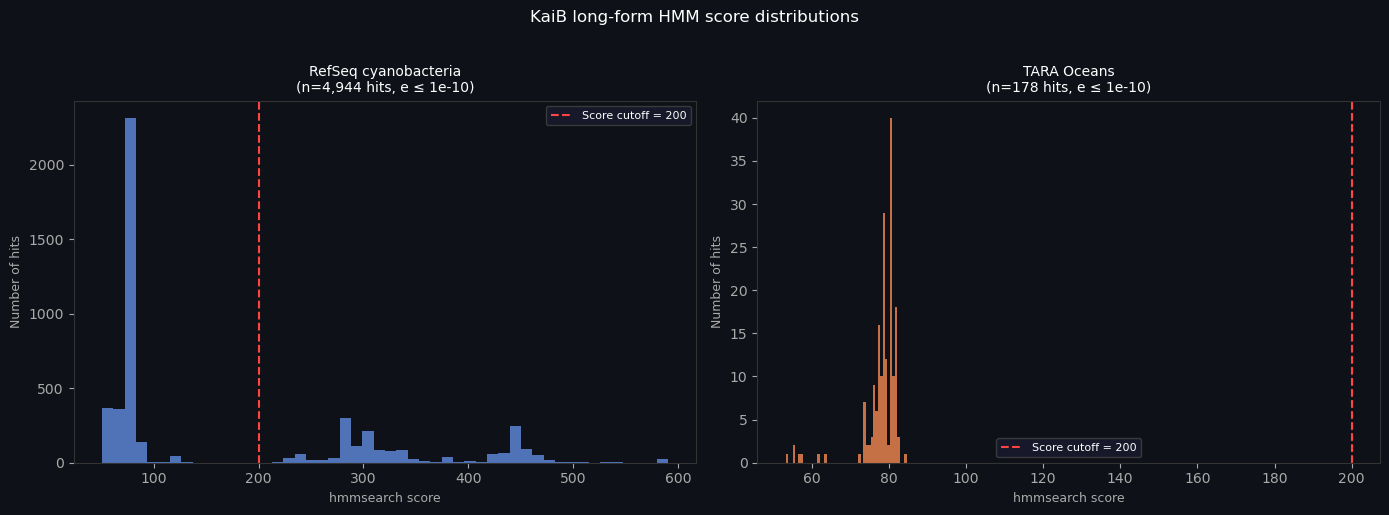

Saved → longKaiB_score_distributions.pdf


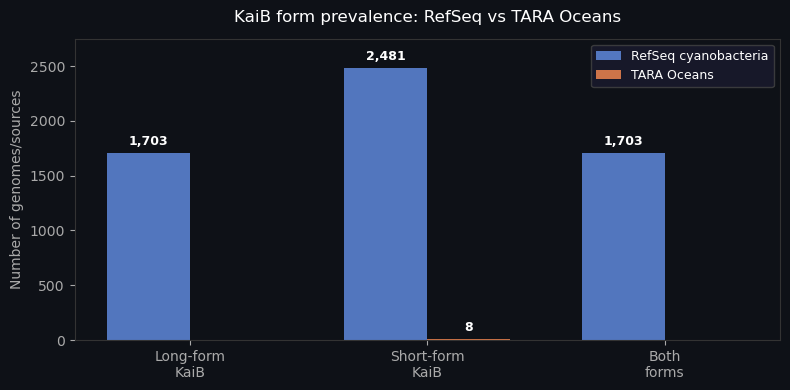

Saved → longKaiB_refseq_vs_tara.pdf


In [30]:
# ── 10. Combined RefSeq + TARA visualization ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG = '#0e1117'

# ── Panel A: Score distribution comparison ───────────────────────────────────
# Show the score distributions for TARA hits to verify the same bimodal
# separation seen in RefSeq data

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# RefSeq score distribution (all hits above e-value cutoff, no score filter)
refseq_all_rows = []
with open(TBLOUT) as f:
    for line in f:
        if line.startswith("#") or not line.strip(): continue
        cols = line.split()
        ev = float(cols[4])
        sc = float(cols[5])
        if ev <= EVALUE_CUTOFF:
            refseq_all_rows.append(sc)

tara_all_rows = []
with open(TARA_TBLOUT) as f:
    for line in f:
        if line.startswith("#") or not line.strip(): continue
        cols = line.split()
        ev = float(cols[4])
        sc = float(cols[5])
        if ev <= EVALUE_CUTOFF:
            tara_all_rows.append(sc)

for ax_i, (scores, label, color) in enumerate([
    (refseq_all_rows, "RefSeq cyanobacteria", "#5C85D6"),
    (tara_all_rows,   "TARA Oceans",          "#E8824E"),
]):
    ax = axes[ax_i]
    ax.set_facecolor(BG)
    if scores:
        ax.hist(scores, bins=50, color=color, alpha=0.85, edgecolor='none')
        ax.axvline(SCORE_CUTOFF, color='#ff4444', linestyle='--', linewidth=1.5,
                   label=f'Score cutoff = {SCORE_CUTOFF:.0f}')
    ax.set_xlabel('hmmsearch score', color='#aaa', fontsize=9)
    ax.set_ylabel('Number of hits', color='#aaa', fontsize=9)
    ax.set_title(f'{label}\n(n={len(scores):,} hits, e ≤ {EVALUE_CUTOFF:.0e})',
                 color='white', fontsize=10)
    ax.tick_params(colors='#aaa')
    ax.spines[:].set_color('#333')
    ax.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

plt.suptitle('KaiB long-form HMM score distributions',
             color='white', fontsize=12, y=1.02)
plt.tight_layout()
out = FIG_DIR / 'longKaiB_score_distributions.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"Saved → {out.name}")

# ── Panel B: Summary comparison bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
ax.set_facecolor(BG)

categories = ['Long-form\nKaiB', 'Short-form\nKaiB', 'Both\nforms']

refseq_vals = [len(long_accs), len(short_accs), n_both]
tara_long_n = len(tara_long_sources)
tara_short_n = len(tara_short_sources)
tara_both_n = len(tara_long_sources & tara_short_sources)
tara_vals = [tara_long_n, tara_short_n, tara_both_n]

x = np.arange(len(categories))
w = 0.35

bars1 = ax.bar(x - w/2, refseq_vals, w, label='RefSeq cyanobacteria', color='#5C85D6', alpha=0.88)
bars2 = ax.bar(x + w/2, tara_vals,   w, label='TARA Oceans',          color='#E8824E', alpha=0.88)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + max(refseq_vals)*0.02,
                    f'{int(h):,}', ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, color='white')
ax.set_ylim([0,2750])
ax.set_ylabel('Number of genomes/sources', color='#aaa', fontsize=10)
ax.tick_params(colors='#aaa')
ax.spines[:].set_color('#333')
ax.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
ax.set_title('KaiB form prevalence: RefSeq vs TARA Oceans',
             color='white', fontsize=12, pad=12)

plt.tight_layout()
out = FIG_DIR / 'longKaiB_refseq_vs_tara.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"Saved → {out.name}")
